In [25]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import file_paths
import helper_functions

import eelbrain
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [26]:
# Make average TRFs across subjects for each model

SUBJECTS = helper_functions.get_subjects()

decoder_trfs = {}

for model in [
    'attended_decoder_trf',
    'attended_decoder_onset_trf',
    'unattended_decoder_trf',
    'unattended_decoder_onset_trf'
]:
    print(f'\nProcessing universal TRF for model: {model}')
    trf_list = []

    for subject in SUBJECTS:
        trf = eelbrain.load.unpickle(file_paths.TRF_DIR / subject / f'{subject}_{model}.pickle').h_scaled
        trf_list.append(trf[0])

    # --- Compute universal TRF ---
    universal_trf = eelbrain.combine(trf_list).mean('case')

    # --- Store in dictionary ---
    decoder_trfs[model] = universal_trf

    print(f"Saved universal TRF for model {model}")


Processing universal TRF for model: attended_decoder_trf
Saved universal TRF for model attended_decoder_trf

Processing universal TRF for model: attended_decoder_onset_trf
Saved universal TRF for model attended_decoder_onset_trf

Processing universal TRF for model: unattended_decoder_trf
Saved universal TRF for model unattended_decoder_trf

Processing universal TRF for model: unattended_decoder_onset_trf
Saved universal TRF for model unattended_decoder_onset_trf


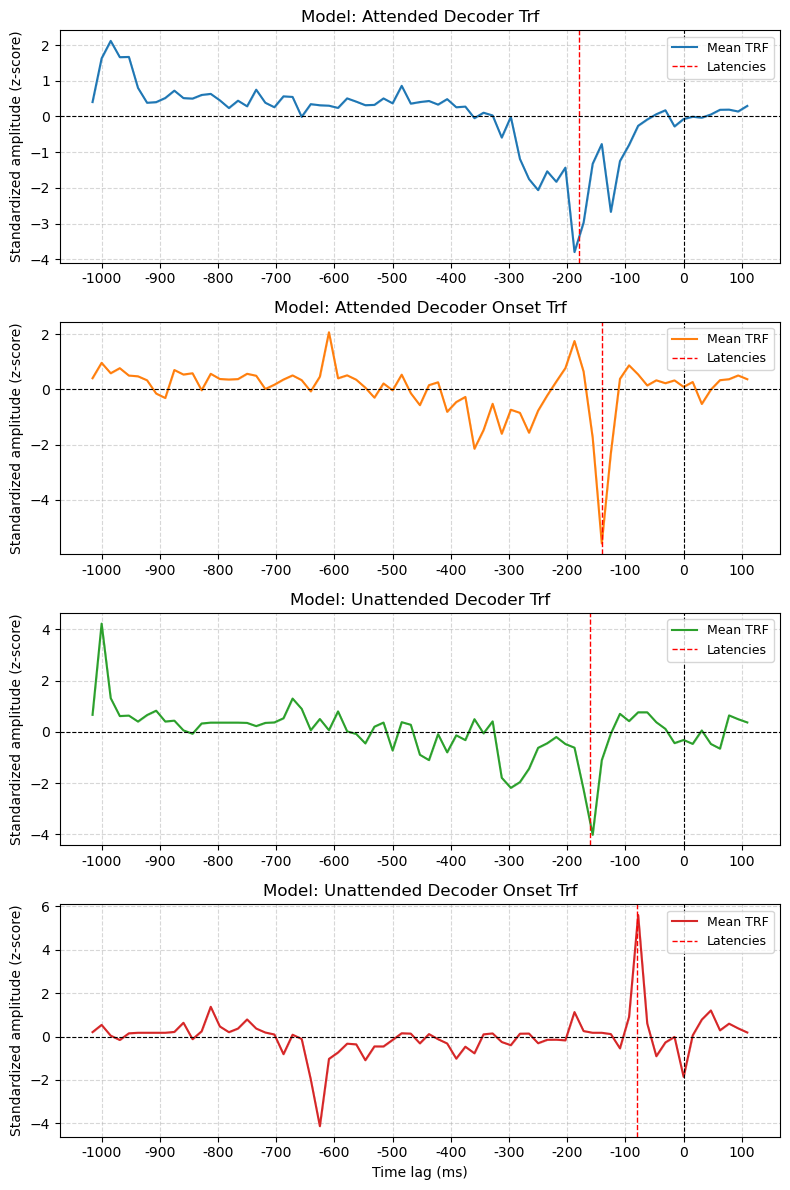

In [30]:
# ------------------------------------------------
# DEFINE LATENCIES (in seconds) PER MODEL
# ------------------------------------------------
latencies_dict = {
    'attended_decoder_trf': [-0.180],    # Envelope TRF latencies
    'attended_decoder_onset_trf': [-0.140],              # Onset TRF latencies
    'unattended_decoder_trf': [-0.160],  # Envelope TRF latencies
    'unattended_decoder_onset_trf': [-0.08]             # Onset TRF latencies
}

# ------------------------------------------------
# Prepare figure
# ------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

colors = {'attended_decoder_trf': 'tab:blue', 'attended_decoder_onset_trf': 'tab:orange', 'unattended_decoder_trf': 'tab:green', 'unattended_decoder_onset_trf': 'tab:red'}

# ------------------------------------------------
# Plot loop
# ------------------------------------------------
for i, model in enumerate(['attended_decoder_trf', 'attended_decoder_onset_trf', 'unattended_decoder_trf', 'unattended_decoder_onset_trf']):
    trf = decoder_trfs[model]

    # Average predictors if present
    if 'predictor' in trf.dims:
        trf_plot = trf.mean('predictor')
        trf_std = trf.std('predictor')
        if hasattr(trf_std, '__array__'):
            trf_std = np.array(trf_std)
    else:
        trf_plot = trf
        trf_std = np.zeros_like(trf_plot.x)

    # ----------------------------------------
    # Convert time to milliseconds
    # ----------------------------------------
    time_ms = np.array(trf_plot.time) * 1000  # <- FIXED

    # ----------------------------------------
    # Standardize
    # ----------------------------------------
    y = (trf_plot.x - np.mean(trf_plot.x)) / np.std(trf_plot.x)
    y_std = trf_std / np.std(trf_plot.x)

    # ----------------------------------------
    # Plot mean TRF
    # ----------------------------------------
    axes[i].plot(time_ms, y, color=colors[model], label='Mean TRF')

    # ----------------------------------------
    # Shaded ±1 SD
    # ----------------------------------------
    axes[i].fill_between(
        time_ms,
        y - y_std,
        y + y_std,
        color=colors[model],
        alpha=0.2
    )

    # ----------------------------------------
    # Vertical latency lines (MODEL-SPECIFIC)
    # ----------------------------------------
    latencies = latencies_dict[model]

    for j, t in enumerate(latencies):
        if j == 0:
            axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1, label='Latencies')
        else:
            axes[i].axvline(t * 1000, color='red', linestyle='--', linewidth=1)

    # ----------------------------------------
    # Formatting
    # ----------------------------------------
    

    axes[i].set_title(f'Model: {model.replace("_", " ").title()}', fontsize=12)
    axes[i].set_ylabel('Standardized amplitude (z-score)')
    axes[i].axhline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].axvline(0, linestyle='--', color='black', linewidth=0.8)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=9)

    # Force x-axis ticks for both plots
    axes[i].xaxis.set_major_locator(MultipleLocator(100))  # every 100 ms
    axes[i].xaxis.set_major_formatter(FormatStrFormatter('%d'))
    axes[i].tick_params(axis='x', labelbottom=True)

# Shared x-axis label
axes[-1].set_xlabel('Time lag (ms)')

plt.tight_layout()
plt.show()

